# Osiris 2026 — Carte des sondes + Évolution humidity_10cm

Exploitation du dump `osiris_2026.csv` (15 sondes). Les sondes 2026 = **mêmes numéros de série
qu'en 2025 mais déployées sur de nouveaux champs** (les coordonnées ne correspondent plus aux
champs connus de 2024/2025). On regroupe ici les sondes par champ (seuil ε = 0.02°), on affiche
la **carte** des sondes, puis la **moyenne journalière de l'humidité à 10 cm par champ**, comme
pour les années précédentes (Visualisation_Osiris.ipynb).

> Sonde **115260** : aucun couple lat/lon → exclue des champs et de la carte (traitée en fin).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import folium
from IPython.display import display

CSV_2026 = "/home/theodore/Documents/Get_Datasets/Osiris_data/osiris_2026.csv"
EPS = 0.02  # seuil de proximité (degrés) pour regrouper les sondes d''un même champ

df = pd.read_csv(CSV_2026)
df["timestamp"] = pd.to_datetime(df["ts"], utc=True)
df["no_serie"] = df["probe_serial_number"]
df["humidity_10cm"] = df["humidity_10cm_value"]

print(f"lignes totales : {len(df)} | sondes : {df['no_serie'].nunique()} | "
      f"{df['timestamp'].min():%Y-%m-%d} → {df['timestamp'].max():%Y-%m-%d}")

lignes totales : 135109 | sondes : 15 | 2026-04-28 → 2026-09-09


In [2]:
# --- 1) Agrégation par sonde (coordonnée principale, count, période) ---
probes = []
for s, g in df.groupby("no_serie"):
    lat = g["latitude"].dropna().mean()
    lon = g["longitude"].dropna().mean()
    probes.append({"no_serie": s, "lat": lat, "lon": lon, "count": len(g),
                   "tmin": g["timestamp"].min(), "tmax": g["timestamp"].max()})
probes.sort(key=lambda x: -x["count"])

# --- 2) Regroupement en champs par proximité (EPS) ---
clusters, assignments = [], {}
for pr in probes:
    if not np.isfinite(pr["lat"]) or not np.isfinite(pr["lon"]):
        assignments[pr["no_serie"]] = None
        continue
    matched = None
    for c in clusters:
        if ((pr["lat"] - c["lat"]) ** 2 + (pr["lon"] - c["lon"]) ** 2) ** 0.5 <= EPS:
            matched = c
            break
    if matched is None:
        matched = {"lat": pr["lat"], "lon": pr["lon"], "members": []}
        clusters.append(matched)
    matched["members"].append(pr["no_serie"])
    assignments[pr["no_serie"]] = clusters.index(matched)

# Nom de champ stable : tri par latitude décroissante -> Champ A, B, ...
order = sorted(range(len(clusters)), key=lambda i: -clusters[i]["lat"])
label = {i: f"Champ {chr(65 + j)}" for j, i in enumerate(order)}

print(f"{'champ':>10} {'lat':>10} {'lon':>10} {'sondes':>24} {'lignes':>7}  période")
for i in sorted(range(len(clusters)), key=lambda k: label[k]):
    c = clusters[i]
    lignes = sum(pr["count"] for pr in probes if pr["no_serie"] in c["members"])
    tmin = min(pr["tmin"] for pr in probes if pr["no_serie"] in c["members"])
    tmax = max(pr["tmax"] for pr in probes if pr["no_serie"] in c["members"])
    print(f"{label[i]:>10} {c['lat']:.5f} {c['lon']:.5f} {str(c['members']):>24} {lignes:>7}  {tmin:%Y-%m-%d} → {tmax:%Y-%m-%d}")

df["field"] = df["no_serie"].map(assignments).map(label)
print("\nlignes affectées à un champ :", df["field"].notna().sum(), "/", len(df))

     champ        lat        lon                   sondes  lignes  période
   Champ A 50.52793 2.78363         [887717, 891481]   24209  2026-05-05 → 2026-09-09
   Champ B 50.36857 1.72880 [1003168, 996652, 996039, 893569]   42374  2026-05-05 → 2026-08-25
   Champ C 49.59812 2.51574         [891515, 996128]   17903  2026-05-23 → 2026-08-24
   Champ D 49.45126 2.65594         [896077, 997113]   18850  2026-04-28 → 2026-08-04
   Champ E 49.43589 2.67567                 [996025]    3991  2026-06-24 → 2026-08-08
   Champ F 49.26498 1.45605                 [895719]    6898  2026-05-23 → 2026-08-03
   Champ G 48.55376 3.87077                 [887587]    8763  2026-05-23 → 2026-08-22
   Champ H 48.32924 2.19956                 [892571]    9408  2026-05-25 → 2026-08-31

lignes affectées à un champ : 132396 / 135109


In [3]:
# --- 3) Carte folium : 1 marqueur par sonde, couleur par champ ---
cmap = colormaps["tab10"].resampled(max(len(clusters), 10))

fc = [folium.FeatureGroup(name=label[i]) for i in range(len(clusters))]
for pr in probes:
    i = assignments[pr["no_serie"]]
    if i is None:
        continue
    r, g, b = (np.array(cmap(i % 10)[:3]) * 255).astype(int)
    popup = (f"<b>{pr['no_serie']}</b><br>{label[i]}<br>"
             f"count = {pr['count']}<br>{pr['tmin']:%Y-%m-%d} → {pr['tmax']:%Y-%m-%d}")
    folium.CircleMarker(
        location=[pr["lat"], pr["lon"]],
        radius=6 + (pr["count"] ** 0.5) * 0.02,
        color=f"#{r:02x}{g:02x}{b:02x}", fill=True,
        fill_color=f"#{r:02x}{g:02x}{b:02x}", fill_opacity=0.85,
        popup=popup,
    ).add_to(fc[i])

m = folium.Map(location=[49.45, 2.6], zoom_start=9)
for f in fc:
    f.add_to(m)
folium.LayerControl().add_to(m)
m.save("carte_points_2026.html")
display(m)
print("Carte sauvegardée : carte_points_2026.html")

Carte sauvegardée : carte_points_2026.html


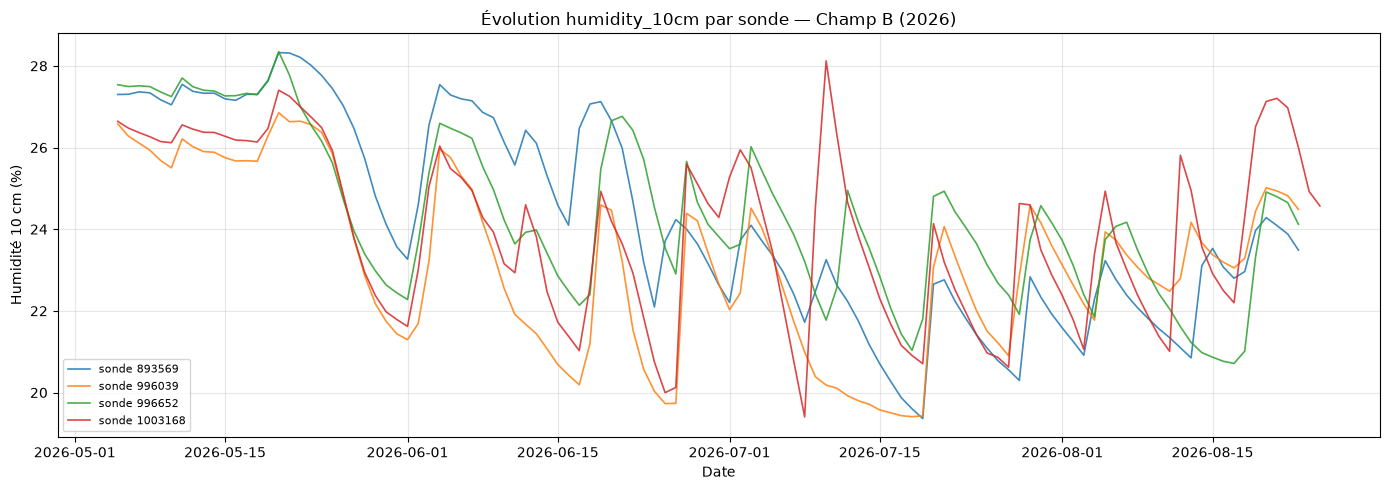

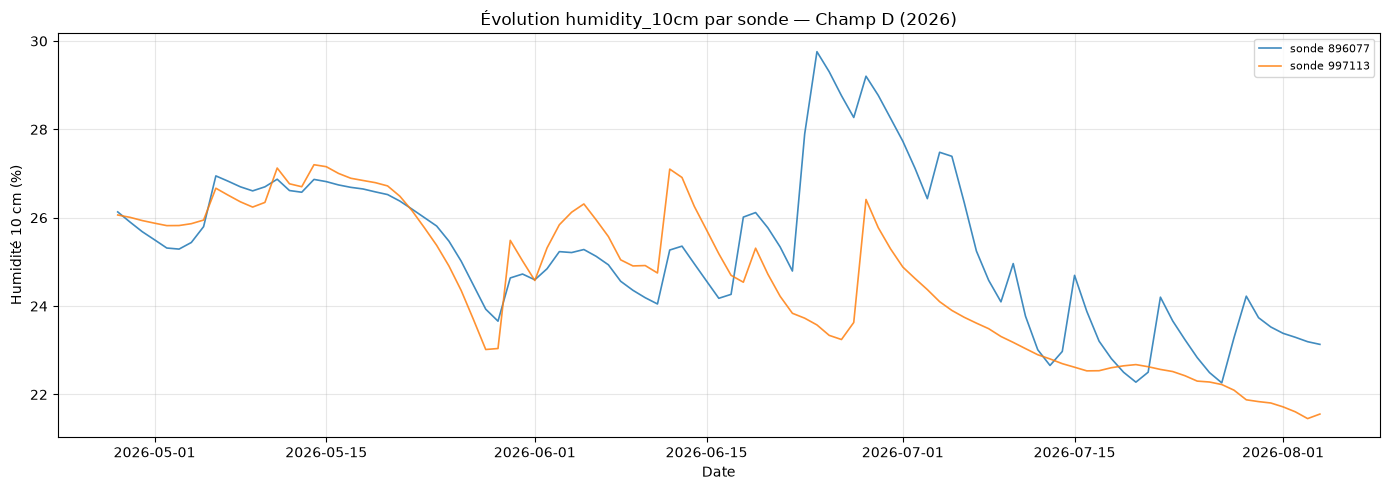

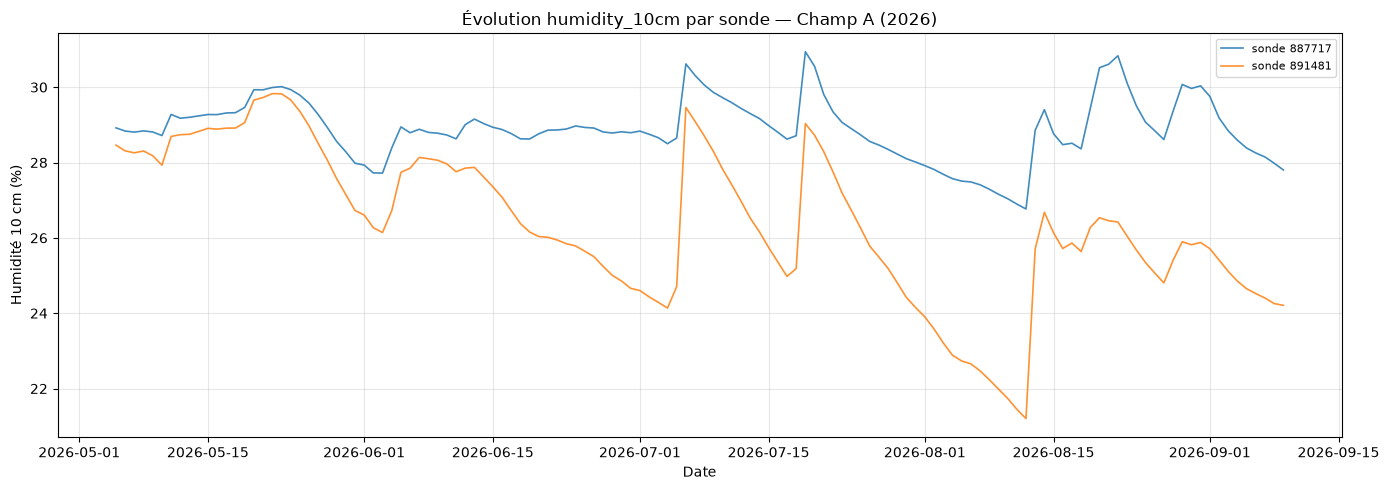

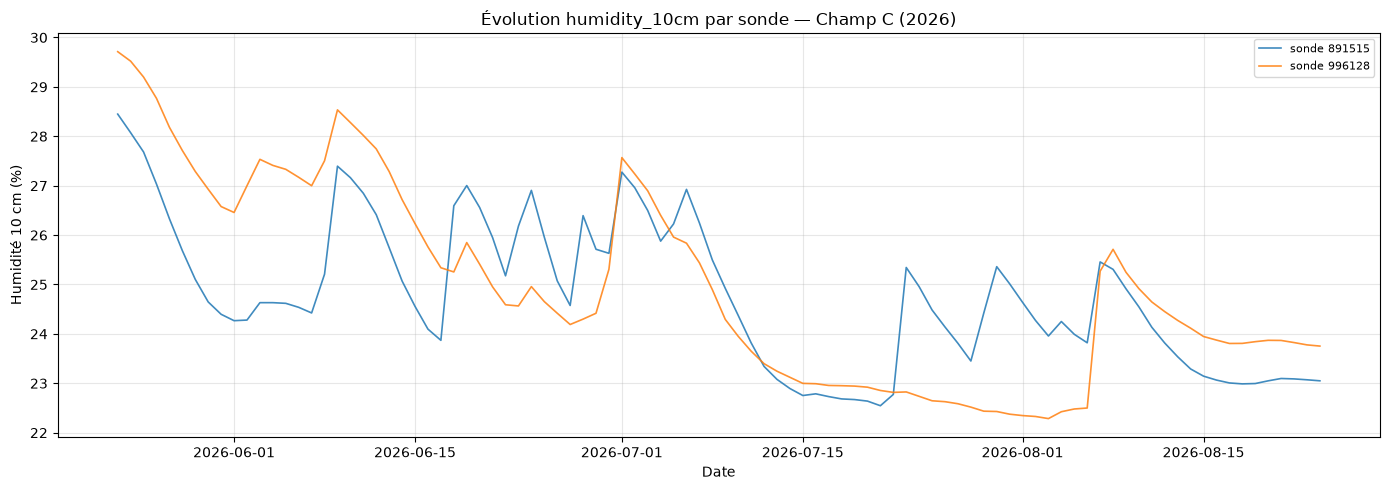

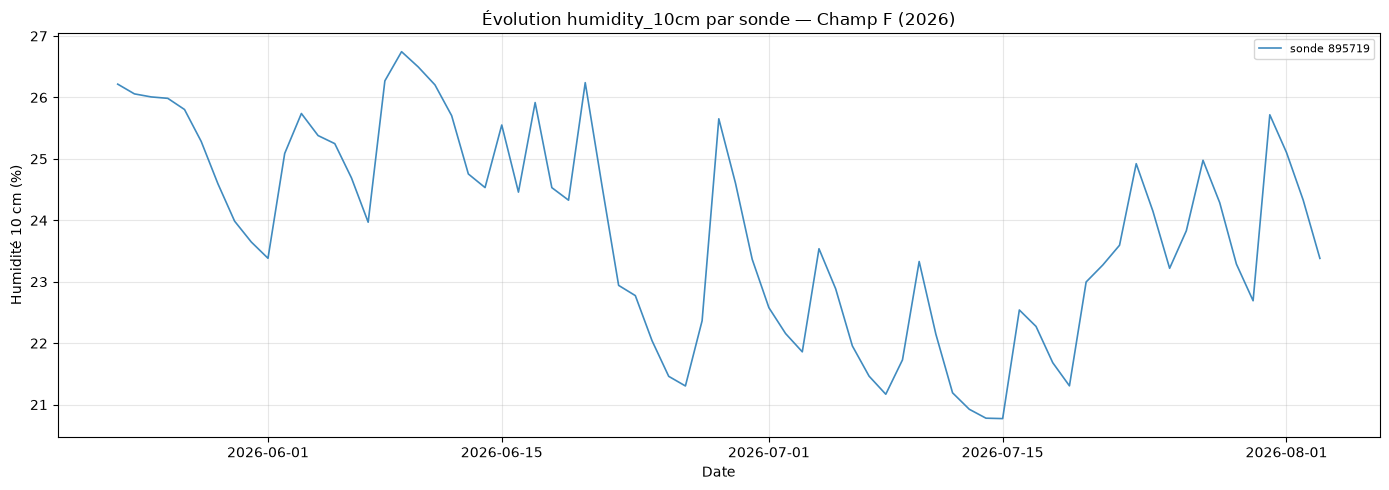

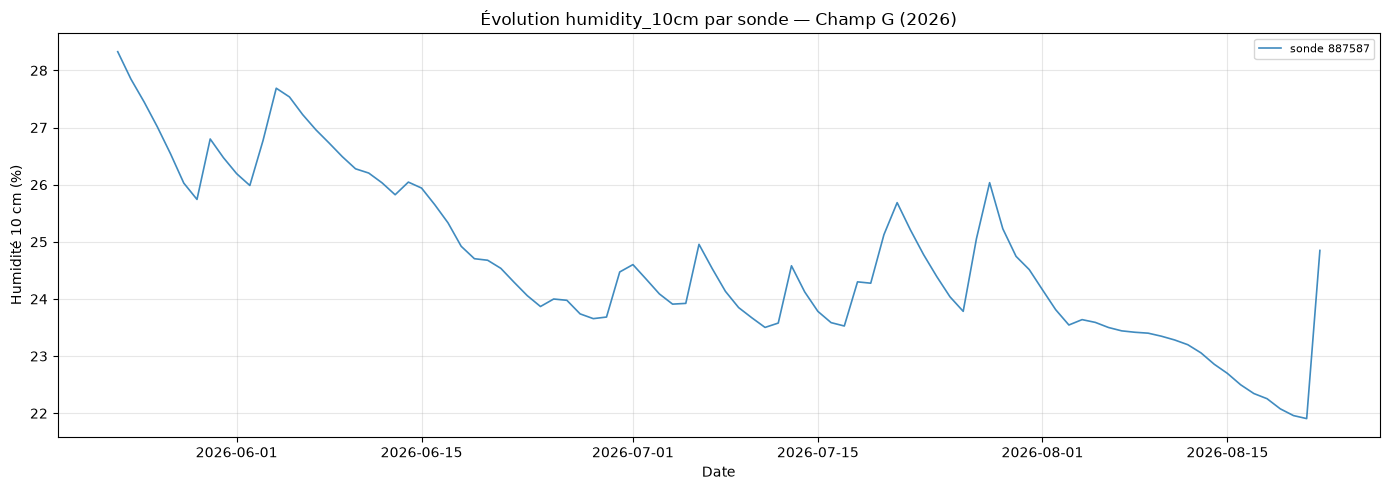

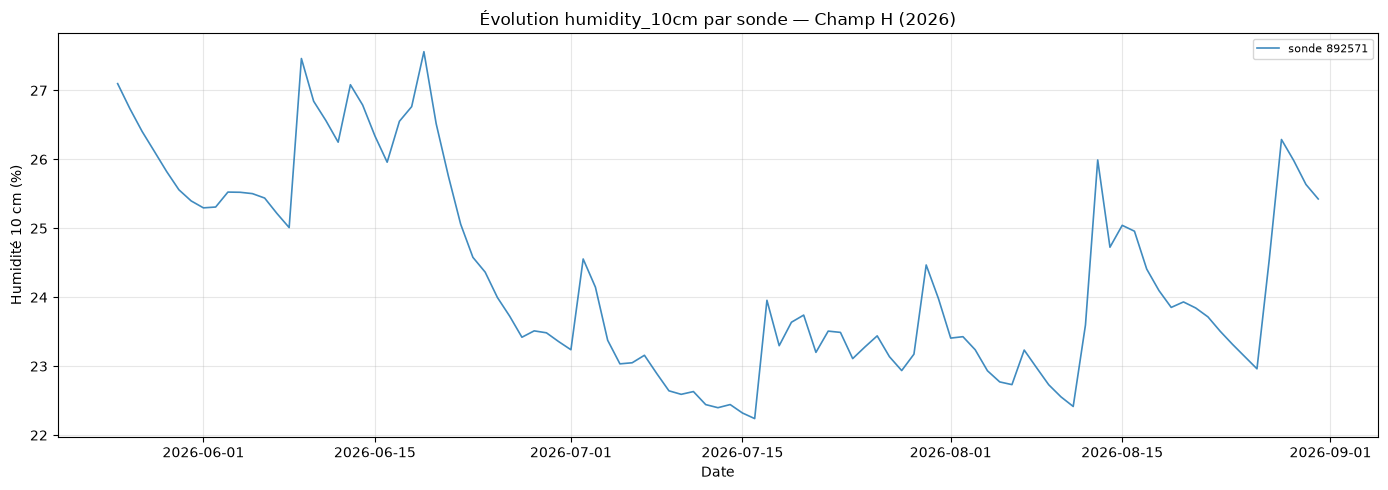

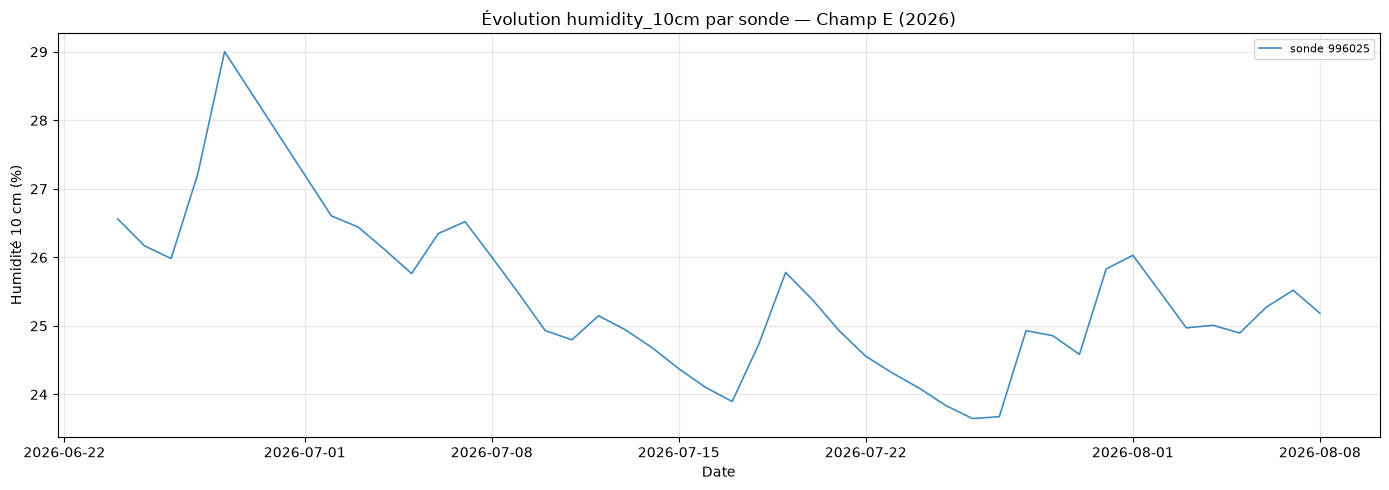

In [4]:
# --- 4) Moyenne journalière humidity_10cm par (champ, sonde) ---
sub = df.dropna(subset=["field", "latitude", "longitude", "humidity_10cm"])
sub = sub[(sub["longitude"] != 0) | (sub["latitude"] != 0)]
sub["date"] = sub["timestamp"].dt.date
daily = sub.groupby(["date", "field", "no_serie"])["humidity_10cm"].mean().reset_index()

# Une figure par champ, une courbe par sonde (même style que 2024/2025)
for field in sorted(daily["field"].unique(),
                    key=lambda f: -daily[daily["field"] == f]["no_serie"].nunique()):
    fdf = daily[daily["field"] == field]
    plt.figure(figsize=(14, 5))
    for j, ns in enumerate(sorted(fdf["no_serie"].unique())):
        g = fdf[fdf["no_serie"] == ns]
        plt.plot(g["date"], g["humidity_10cm"], linewidth=1.2, alpha=0.85, label=f"sonde {ns}")
    plt.xlabel("Date"); plt.ylabel("Humidité 10 cm (%)")
    plt.title(f"Évolution humidity_10cm par sonde — {field} (2026)")
    plt.legend(loc="best", fontsize=8); plt.tight_layout(); plt.grid(True, alpha=0.3)
    plt.show()

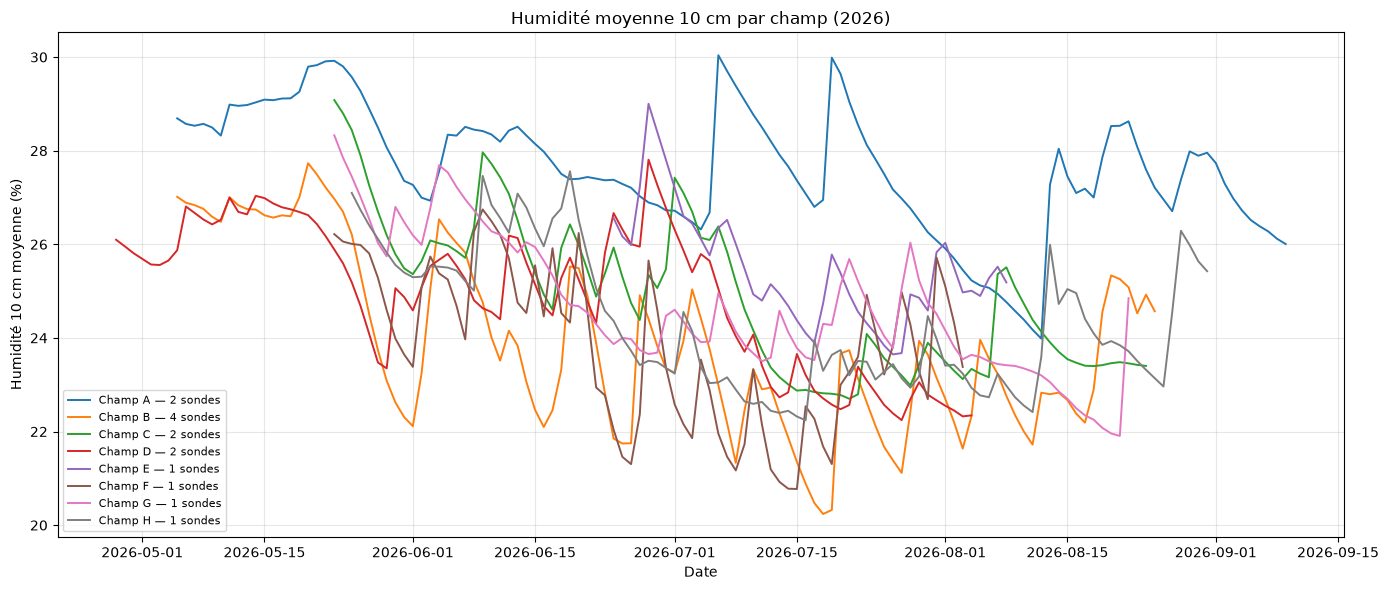


Nombre de mesures par champ / sonde :
field    no_serie
Champ A  887717      12140
         891481      12069
Champ B  893569      10556
         996039      10570
         996652      10571
         1003168     10677
Champ C  891515       8955
         996128       8948
Champ D  896077       9432
         997113       9418
Champ E  996025       3991
Champ F  895719       6898
Champ G  887587       8763
Champ H  892571       9408

Sonde 115260 (exclue des champs) : 2713 mesures horaires, 2026-05-05 → 2026-08-26, coordonnées absentes.


In [5]:
# --- 5) Humidité moyenne à 10 cm par champ (courbe unique) + récap ---
daily_mean = daily.groupby(["date", "field"])["humidity_10cm"].mean().reset_index()
n_sonde = sub.groupby("field")["no_serie"].nunique()

plt.figure(figsize=(14, 6))
for j, field in enumerate(sorted(daily_mean["field"].unique())):
    g = daily_mean[daily_mean["field"] == field]
    plt.plot(g["date"], g["humidity_10cm"], linewidth=1.4, label=f"{field} — {n_sonde[field]} sondes")
plt.xlabel("Date"); plt.ylabel("Humidité 10 cm moyenne (%)")
plt.title("Humidité moyenne 10 cm par champ (2026)")
plt.legend(loc="best", fontsize=8); plt.tight_layout(); plt.grid(True, alpha=0.3)
plt.show()

print("\nNombre de mesures par champ / sonde :")
print(sub.groupby(["field", "no_serie"]).size().to_string())

g115 = df[df["no_serie"] == 115260].set_index("timestamp").sort_index()
print(f"\nSonde 115260 (exclue des champs) : {len(g115)} mesures horaires, "
      f"{g115.index.min():%Y-%m-%d} → {g115.index.max():%Y-%m-%d}, coordonnées absentes.")